In [25]:
import pandas as pd
import numpy as np

In [2]:

df_products = pd.read_csv("fashion_boutique_dataset.csv")
df_costs = pd.read_csv("true_cost_fast_fashion.csv")
df_wage = pd.read_csv("country-monthlylivableusd.csv")

In [24]:
df_wage = pd.read_csv("country-monthlylivableusd.csv")
df_wage

,country,monthly_livable_usd
0,Indonesia,102
1,Vietnam,205
2,India,136
3,USA,1660
4,Turkey,282
5,Brazil,257
6,Bangladesh,95
7,China,315
8,Germany,1397
9,UK,1103


In [3]:
df_products['brand'].unique() 

<ArrowStringArray>
[           'Zara',          'Uniqlo', 'Banana Republic',           'Mango',
             'H&M',      'Ann Taylor',             'Gap',       'Forever21']
Length: 8, dtype: str

In [4]:
df_costs['Brand'].unique()

<ArrowStringArray>
['Shein', 'Forever 21', 'Uniqlo', 'Zara', 'H&M']
Length: 5, dtype: str

In [5]:
df_costs['Country'].unique()

<ArrowStringArray>
[ 'Indonesia',    'Vietnam',      'India',        'USA',     'Turkey',
     'Brazil', 'Bangladesh',      'China',    'Germany',         'UK']
Length: 10, dtype: str

In [22]:
df_products['brand_cleaned'] = df_products['brand'].str.replace(" ", "")
df_costs['brand_cleaned'] = df_costs['Brand'].str.replace(" ", "")

similar_brands = ['H&M', 'Uniqlo', 'Zara', "Forever21"]

df_products_filtered = df_products[df_products['brand_cleaned'].isin(similar_brands)]
df_costs_filtered = df_costs[df_costs['brand_cleaned'].isin(similar_brands)]





In [7]:
df_products_filtered

,product_id,category,brand,season,size,color,original_price,markdown_percentage,current_price,purchase_date,stock_quantity,customer_rating,is_returned,return_reason,brand_cleaned
0,FB000001,Outerwear,Zara,Spring,XL,Red,196.01,0.0,196.01,2025-07-05,37,3.0,False,NaN,Zara
1,FB000002,Tops,Uniqlo,Winter,L,Pink,119.64,0.0,119.64,2025-08-06,2,2.5,False,NaN,Uniqlo
2,FB000003,Accessories,Uniqlo,Winter,NaN,Black,33.80,0.0,33.80,2025-08-06,22,4.3,False,NaN,Uniqlo
3,FB000004,Shoes,Uniqlo,Spring,XL,Black,75.36,0.0,75.36,2025-07-07,48,2.6,False,NaN,Uniqlo
5,FB000006,Accessories,Zara,Fall,NaN,White,35.03,35.4,22.63,2025-08-06,38,2.9,True,Color Mismatch,Zara
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163,FB002164,Shoes,H&M,Spring,XL,White,178.56,0.0,178.56,2025-03-16,46,2.6,False,NaN,H&M
2164,FB002165,Accessories,Uniqlo,Summer,NaN,Green,30.46,31.4,20.90,2025-08-06,40,2.4,False,NaN,Uniqlo
2167,FB002168,Shoes,H&M,Winter,XS,White,98.22,0.0,98.22,2025-08-06,27,3.3,False,NaN,H&M
2169,FB002170,Accessories,Uniqlo,Spring,NaN,Beige,69.22,0.0,69.22,2024-09-05,42,3.8,False,NaN,Uniqlo


In [8]:
df_costs_filtered

,Brand,Country,Year,Monthly_Production_Tonnes,Avg_Item_Price_USD,Release_Cycles_Per_Year,Carbon_Emissions_tCO2e,Water_Usage_Million_Litres,Landfill_Waste_Tonnes,Avg_Worker_Wage_USD,...,TikTok_Mentions_Thousands,Sentiment_Score,Social_Sentiment_Label,GDP_Contribution_Million_USD,Env_Cost_Index,Sustainability_Score,Transparency_Index,Compliance_Score,Ethical_Rating,brand_cleaned
1,Forever 21,Vietnam,2024,394.50,9.30,20,5571.01,289.22,795.11,167.78,...,6285,-0.12,Positive,689.49,0.21,49.52,3.44,90.93,1.29,Forever21
2,Uniqlo,India,2024,310.23,25.46,11,10969.00,116.39,364.33,97.81,...,387,0.08,Neutral,439.78,0.63,96.53,60.70,27.60,1.48,Uniqlo
3,Forever 21,USA,2017,218.65,13.17,13,13093.00,255.88,632.16,134.54,...,1620,-0.06,Neutral,746.70,0.21,71.32,76.08,56.13,3.85,Forever21
4,Zara,Indonesia,2016,1005.84,15.40,20,9548.40,142.07,830.10,144.33,...,3292,-0.59,Neutral,571.42,0.95,59.89,69.48,88.05,3.12,Zara
5,H&M,Indonesia,2017,408.45,18.42,17,14115.59,210.53,738.14,183.66,...,3798,0.38,Neutral,398.67,0.34,24.41,16.83,21.88,2.79,H&M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2991,H&M,Indonesia,2019,313.98,27.10,22,12423.61,163.15,423.40,112.33,...,7739,-0.90,Neutral,474.50,0.73,74.39,45.72,53.83,3.75,H&M
2993,H&M,Indonesia,2017,551.89,26.74,24,10503.79,275.80,1063.83,144.95,...,6757,-0.32,Positive,85.29,0.99,46.57,43.52,48.37,4.60,H&M
2995,Zara,India,2020,549.36,17.77,21,11214.01,87.08,768.13,165.22,...,3053,0.06,Negative,582.87,0.99,26.52,21.80,33.48,2.63,Zara
2997,Zara,China,2023,370.31,22.25,22,3385.09,211.81,906.82,104.30,...,4743,-0.71,Negative,607.47,0.75,42.57,75.29,55.28,0.20,Zara


In [9]:
df_cost_brand = df_costs_filtered.groupby("brand_cleaned").agg({
    "Carbon_Emissions_tCO2e": "mean",
    "Water_Usage_Million_Litres": "mean",
    "Landfill_Waste_Tonnes": "mean",
    "Monthly_Production_Tonnes": "mean",
    "Release_Cycles_Per_Year": "mean",
    "Avg_Item_Price_USD": "mean",
    "Avg_Worker_Wage_USD": "mean"
}).reset_index()

df_cost_brand

,brand_cleaned,Carbon_Emissions_tCO2e,Water_Usage_Million_Litres,Landfill_Waste_Tonnes,Monthly_Production_Tonnes,Release_Cycles_Per_Year,Avg_Item_Price_USD,Avg_Worker_Wage_USD
0,Forever21,9933.496596,204.151524,806.964133,497.603517,17.703404,19.851507,148.124360
1,H&M,10084.840031,197.993338,791.433800,500.261292,17.749231,19.798000,150.729800
2,Uniqlo,10097.616420,204.579880,789.363201,489.621188,17.621343,19.960964,148.684940
3,Zara,9945.682261,202.061403,794.568927,497.465264,17.704620,19.994950,149.846832


In [10]:
df_cost_country = df_costs_filtered.groupby(
    ["brand_cleaned", "Country"]
).agg({
    "Carbon_Emissions_tCO2e": "mean",
    "Water_Usage_Million_Litres": "mean",
    "Landfill_Waste_Tonnes": "mean",
    "Monthly_Production_Tonnes": "mean",
    "Release_Cycles_Per_Year": "mean",
    "Avg_Item_Price_USD": "mean",
    "Avg_Worker_Wage_USD": "mean"
}).reset_index()

df_cost_country

,brand_cleaned,Country,Carbon_Emissions_tCO2e,Water_Usage_Million_Litres,Landfill_Waste_Tonnes,Monthly_Production_Tonnes,Release_Cycles_Per_Year,Avg_Item_Price_USD,Avg_Worker_Wage_USD
0,Forever21,Bangladesh,9708.855000,212.020357,786.367143,513.114643,18.910714,18.842679,151.181786
1,Forever21,Brazil,10429.961692,198.505385,801.952308,465.764923,18.323077,21.410615,144.389077
2,Forever21,China,10127.908478,202.323261,854.599783,498.805000,17.630435,18.946304,153.803913
3,Forever21,Germany,9743.232750,203.232375,827.641875,497.138125,17.050000,19.050250,153.536625
4,Forever21,India,10107.376774,206.963226,733.617742,517.477742,18.387097,20.394516,146.811774
5,Forever21,Indonesia,10390.980725,204.806667,834.133188,479.232609,16.710145,21.372609,142.411739
6,Forever21,Turkey,9418.321915,203.316809,769.860851,512.098511,18.042553,20.100638,152.839149
7,Forever21,UK,9920.512239,207.858955,837.662388,523.935970,18.283582,20.081791,140.046716
8,Forever21,USA,9781.560794,206.151429,787.910159,509.047460,16.412698,18.509206,149.874286
9,Forever21,Vietnam,9593.109516,196.559355,826.222581,466.179839,17.709677,19.524032,149.128387


In [26]:


# 2. Clean country names
df_cost_country["Country"] = df_cost_country["Country"].str.strip()
df_wage["country"] = df_wage["country"].str.strip()

# 3. Merge cost data with livable wage benchmark
df_merged = df_cost_country.merge(
    df_wage,
    left_on="Country",
    right_on="country",
    how="left"
)

# 4. Drop countries that do not fit the factory-wage benchmark context
drop_countries = ["USA", "UK", "Germany"]

df_filtered = df_merged[
    ~df_merged["Country"].isin(drop_countries)
].copy()

# 5. Create wage benchmark features BEFORE grouping
df_filtered["Wage_Gap_USD"] = (
    df_filtered["Avg_Worker_Wage_USD"] - df_filtered["monthly_livable_usd"]
)

df_filtered["Wage_Ratio"] = (
    df_filtered["Avg_Worker_Wage_USD"] / df_filtered["monthly_livable_usd"]
)

df_filtered["Meets_Living_Wage"] = (
    df_filtered["Wage_Ratio"] >= 1
)

# 6. Build brand-country dataset
df_brand_country = df_filtered.groupby(
    ["brand_cleaned", "Country"]
).agg(
    Avg_Worker_Wage=("Avg_Worker_Wage_USD", "mean"),
    Livable_Wage=("monthly_livable_usd", "mean"),
    Wage_Gap_USD=("Wage_Gap_USD", "mean"),
    Wage_Ratio=("Wage_Ratio", "mean"),
    Meets_Living_Wage_Rate=("Meets_Living_Wage", "mean")
).reset_index()

# 7. Format columns
df_brand_country["Wage_Gap_Pct"] = (
    (df_brand_country["Wage_Ratio"] - 1) * 100
)

df_brand_country["Meets_Living_Wage_Rate"] = (
    df_brand_country["Meets_Living_Wage_Rate"] * 100
)

# 8. Add risk labels
df_brand_country["Labor_Risk_Level"] = pd.cut(
    df_brand_country["Wage_Ratio"],
    bins=[-np.inf, 0.8, 1.0, np.inf],
    labels=["High Risk", "Medium Risk", "Low Risk"]
)

# 9. Round for readability
df_brand_country = df_brand_country.round({
    "Avg_Worker_Wage": 2,
    "Livable_Wage": 2,
    "Wage_Gap_USD": 2,
    "Wage_Ratio": 2,
    "Wage_Gap_Pct": 1,
    "Meets_Living_Wage_Rate": 1
})

# 10. Display final dataset
display(
    df_brand_country.sort_values(["brand_cleaned", "Country"])
)

# 11. Optional: brand-level labor summary
df_labor_brand_summary = df_brand_country.groupby("brand_cleaned").agg(
    Avg_Wage_Ratio=("Wage_Ratio", "mean"),
    Avg_Wage_Gap_USD=("Wage_Gap_USD", "mean"),
    Living_Wage_Compliance_Rate=("Meets_Living_Wage_Rate", "mean"),
    High_Risk_Countries=("Labor_Risk_Level", lambda x: (x == "High Risk").sum())
).reset_index()

df_labor_brand_summary = df_labor_brand_summary.round(2)

display(df_labor_brand_summary)

,brand_cleaned,Country,Avg_Worker_Wage,Livable_Wage,Wage_Gap_USD,Wage_Ratio,Meets_Living_Wage_Rate,Wage_Gap_Pct,Labor_Risk_Level
0,Forever21,Bangladesh,151.18,95.0,56.18,1.59,100.0,59.1,Low Risk
1,Forever21,Brazil,144.39,257.0,-112.61,0.56,0.0,-43.8,High Risk
2,Forever21,China,153.80,315.0,-161.20,0.49,0.0,-51.2,High Risk
3,Forever21,India,146.81,136.0,10.81,1.08,100.0,7.9,Low Risk
4,Forever21,Indonesia,142.41,102.0,40.41,1.40,100.0,39.6,Low Risk
5,Forever21,Turkey,152.84,282.0,-129.16,0.54,0.0,-45.8,High Risk
6,Forever21,Vietnam,149.13,205.0,-55.87,0.73,0.0,-27.3,High Risk
7,H&M,Bangladesh,150.49,95.0,55.49,1.58,100.0,58.4,Low Risk
8,H&M,Brazil,155.14,257.0,-101.86,0.60,0.0,-39.6,High Risk
9,H&M,China,157.12,315.0,-157.88,0.50,0.0,-50.1,High Risk


,brand_cleaned,Avg_Wage_Ratio,Avg_Wage_Gap_USD,Living_Wage_Compliance_Rate,High_Risk_Countries
0,Forever21,0.91,-50.21,42.86,4
1,H&M,0.92,-46.64,42.86,4
2,Uniqlo,0.91,-51.65,42.86,4
3,Zara,0.91,-48.99,42.86,4


In [12]:
df_cost_brand = df_cost_brand.drop(columns=["Brand"], errors="ignore")
df_cost_brand = df_cost_brand.rename(columns={"brand_cleaned": "brand"})

df_final = df_products_filtered.merge(
    df_cost_brand,
    on="brand",
    how="inner"
)

In [13]:
df_final 

,product_id,category,brand,season,size,color,original_price,markdown_percentage,current_price,purchase_date,...,is_returned,return_reason,brand_cleaned,Carbon_Emissions_tCO2e,Water_Usage_Million_Litres,Landfill_Waste_Tonnes,Monthly_Production_Tonnes,Release_Cycles_Per_Year,Avg_Item_Price_USD,Avg_Worker_Wage_USD
0,FB000001,Outerwear,Zara,Spring,XL,Red,196.01,0.0,196.01,2025-07-05,...,False,NaN,Zara,9945.682261,202.061403,794.568927,497.465264,17.704620,19.994950,149.846832
1,FB000002,Tops,Uniqlo,Winter,L,Pink,119.64,0.0,119.64,2025-08-06,...,False,NaN,Uniqlo,10097.616420,204.579880,789.363201,489.621188,17.621343,19.960964,148.684940
2,FB000003,Accessories,Uniqlo,Winter,NaN,Black,33.80,0.0,33.80,2025-08-06,...,False,NaN,Uniqlo,10097.616420,204.579880,789.363201,489.621188,17.621343,19.960964,148.684940
3,FB000004,Shoes,Uniqlo,Spring,XL,Black,75.36,0.0,75.36,2025-07-07,...,False,NaN,Uniqlo,10097.616420,204.579880,789.363201,489.621188,17.621343,19.960964,148.684940
4,FB000006,Accessories,Zara,Fall,NaN,White,35.03,35.4,22.63,2025-08-06,...,True,Color Mismatch,Zara,9945.682261,202.061403,794.568927,497.465264,17.704620,19.994950,149.846832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1101,FB002164,Shoes,H&M,Spring,XL,White,178.56,0.0,178.56,2025-03-16,...,False,NaN,H&M,10084.840031,197.993338,791.433800,500.261292,17.749231,19.798000,150.729800
1102,FB002165,Accessories,Uniqlo,Summer,NaN,Green,30.46,31.4,20.90,2025-08-06,...,False,NaN,Uniqlo,10097.616420,204.579880,789.363201,489.621188,17.621343,19.960964,148.684940
1103,FB002168,Shoes,H&M,Winter,XS,White,98.22,0.0,98.22,2025-08-06,...,False,NaN,H&M,10084.840031,197.993338,791.433800,500.261292,17.749231,19.798000,150.729800
1104,FB002170,Accessories,Uniqlo,Spring,NaN,Beige,69.22,0.0,69.22,2024-09-05,...,False,NaN,Uniqlo,10097.616420,204.579880,789.363201,489.621188,17.621343,19.960964,148.684940


In [14]:
import pandas as pd
import numpy as np

# Build brand-level dataset from the costs table
df_brand = df_costs_filtered.groupby("brand_cleaned").agg({
    "Carbon_Emissions_tCO2e": "mean",
    "Water_Usage_Million_Litres": "mean",
    "Landfill_Waste_Tonnes": "mean",
    "Monthly_Production_Tonnes": "mean",
    "Release_Cycles_Per_Year": "mean",
    "Avg_Item_Price_USD": "mean",
    "Avg_Worker_Wage_USD": "mean",
    "TikTok_Mentions_Thousands": "mean",
    "Sentiment_Score": "mean",
    "GDP_Contribution_Million_USD": "mean",
    "Env_Cost_Index": "mean",
    "Sustainability_Score": "mean",
    "Transparency_Index": "mean",
    "Compliance_Score": "mean",
    "Ethical_Rating": "mean"
}).reset_index()

# Rename brand column for cleaner plotting / interpretation
df_brand = df_brand.rename(columns={"brand_cleaned": "brand"})

print(df_brand.shape)
display(df_brand)

(4, 16)


,brand,Carbon_Emissions_tCO2e,Water_Usage_Million_Litres,Landfill_Waste_Tonnes,Monthly_Production_Tonnes,Release_Cycles_Per_Year,Avg_Item_Price_USD,Avg_Worker_Wage_USD,TikTok_Mentions_Thousands,Sentiment_Score,GDP_Contribution_Million_USD,Env_Cost_Index,Sustainability_Score,Transparency_Index,Compliance_Score,Ethical_Rating
0,Forever21,9933.496596,204.151524,806.964133,497.603517,17.703404,19.851507,148.124360,3897.048622,-0.009433,497.179611,0.552058,49.599028,50.977796,50.662139,2.542771
1,H&M,10084.840031,197.993338,791.433800,500.261292,17.749231,19.798000,150.729800,3993.896923,-0.020600,508.633200,0.561277,50.326646,49.369415,49.923015,2.503569
2,Uniqlo,10097.616420,204.579880,789.363201,489.621188,17.621343,19.960964,148.684940,4063.154905,0.024355,496.346472,0.541549,49.732840,47.848313,49.294492,2.552685
3,Zara,9945.682261,202.061403,794.568927,497.465264,17.704620,19.994950,149.846832,3945.245875,-0.023564,501.830363,0.564356,47.796551,50.613696,48.735314,2.504950


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Features for PCA
pca_features = [
    "Carbon_Emissions_tCO2e",
    "Water_Usage_Million_Litres",
    "Landfill_Waste_Tonnes",
    "Monthly_Production_Tonnes",
    "Release_Cycles_Per_Year",
    "Avg_Item_Price_USD",
    "Avg_Worker_Wage_USD",
    "TikTok_Mentions_Thousands",
    "Sentiment_Score",
    "GDP_Contribution_Million_USD",
    "Env_Cost_Index",
    "Sustainability_Score",
    "Transparency_Index",
    "Compliance_Score",
    "Ethical_Rating"
]

X = df_brand[pca_features]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# Add components back
df_brand["PC1"] = components[:, 0]
df_brand["PC2"] = components[:, 1]

# Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)

# PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1_loading", "PC2_loading"],
    index=pca_features
).sort_values("PC1_loading", key=np.abs, ascending=False)

display(loadings)
display(df_brand[["brand", "PC1", "PC2"]])

Explained variance ratio: [0.49578103 0.30282753]


,PC1_loading,PC2_loading
Monthly_Production_Tonnes,0.358707,0.052381
Release_Cycles_Per_Year,0.358210,-0.005603
Sentiment_Score,-0.358082,-0.068617
Env_Cost_Index,0.345584,-0.015869
Ethical_Rating,-0.323965,0.158022
GDP_Contribution_Million_USD,0.294942,-0.275214
Water_Usage_Million_Litres,-0.287305,0.281848
Avg_Worker_Wage_USD,0.248043,-0.336203
Transparency_Index,0.241455,0.348965
TikTok_Mentions_Thousands,-0.213356,-0.381348


,brand,PC1,PC2
0,Forever21,0.071892,3.214308
1,H&M,2.776303,-2.430660
2,Uniqlo,-4.422241,-1.292577
3,Zara,1.574045,0.508929


In [16]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df_brand["PC1"],
    df_brand["PC2"],
    s=150,
    c=df_brand["Ethical_Rating"]
)

for _, row in df_brand.iterrows():
    plt.text(row["PC1"] + 0.03, row["PC2"] + 0.03, row["brand"], fontsize=11)

plt.colorbar(scatter, label="Ethical Rating")
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Brand Positioning Colored by Ethical Rating")
plt.show()

NameError: name 'plt' is not defined

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(df_brand["PC1"], df_brand["Ethical_Rating"], s=120)

for _, row in df_brand.iterrows():
    plt.text(row["PC1"] + 0.02, row["Ethical_Rating"], row["brand"])

plt.xlabel("Production / Scale (PC1)")
plt.ylabel("Ethical Rating")
plt.title("Scale vs Ethics Tradeoff")
plt.show()

NameError: name 'plt' is not defined

In [18]:
# -------------------------------
# DEFINE INTERPRETABLE DIMENSIONS
# -------------------------------

scale_features = [
    "Monthly_Production_Tonnes",
    "Release_Cycles_Per_Year",
    "GDP_Contribution_Million_USD"
]

ethics_features = [
    "Avg_Worker_Wage_USD",
    "Transparency_Index",
    "Compliance_Score",
    "Ethical_Rating"
]

sustainability_features = [
    "Carbon_Emissions_tCO2e",
    "Water_Usage_Million_Litres",
    "Landfill_Waste_Tonnes",
    "Env_Cost_Index",
    "Sustainability_Score"
]

# -------------------------------
# CLEANER VERSION: MAKE HIGHER = BETTER
# -------------------------------

from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

df_index = df_brand.copy()

# Flip "bad" sustainability variables so higher means better
df_index["Carbon_Emissions_tCO2e"] = -df_index["Carbon_Emissions_tCO2e"]
df_index["Water_Usage_Million_Litres"] = -df_index["Water_Usage_Million_Litres"]
df_index["Landfill_Waste_Tonnes"] = -df_index["Landfill_Waste_Tonnes"]
df_index["Env_Cost_Index"] = -df_index["Env_Cost_Index"]

all_index_features = scale_features + ethics_features + sustainability_features

scaler = StandardScaler()
df_index[all_index_features] = scaler.fit_transform(df_index[all_index_features])

df_brand["Scale_Index"] = df_index[scale_features].mean(axis=1)
df_brand["Ethics_Index"] = df_index[ethics_features].mean(axis=1)
df_brand["Sustainability_Index"] = df_index[sustainability_features].mean(axis=1)

display(df_brand[["brand", "Scale_Index", "Ethics_Index", "Sustainability_Index"]])

,brand,Scale_Index,Ethics_Index,Sustainability_Index
0,Forever21,-0.083256,0.499879,-0.156380
1,H&M,1.252750,0.113040,0.319723
2,Uniqlo,-1.401203,-0.363787,0.159528
3,Zara,0.231708,-0.249132,-0.322870


,brand,Scale_Index,Ethics_Index,Sustainability_Index
1,H&M,1.252750,0.113040,0.319723
3,Zara,0.231708,-0.249132,-0.322870
0,Forever21,-0.083256,0.499879,-0.156380
2,Uniqlo,-1.401203,-0.363787,0.159528


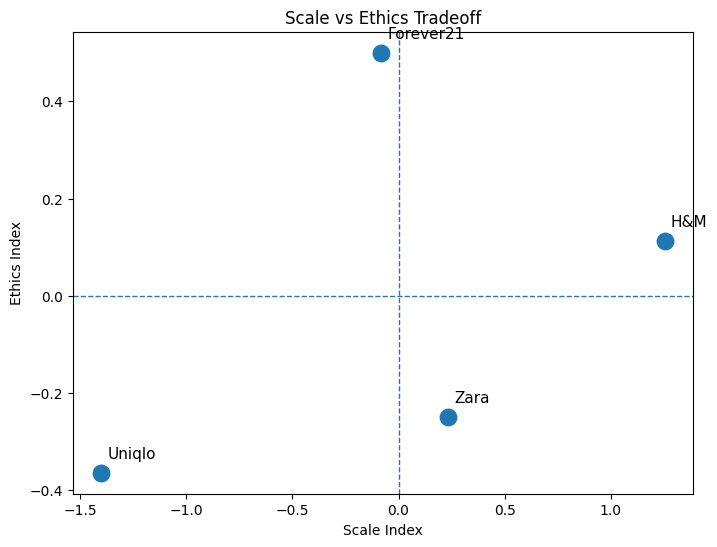

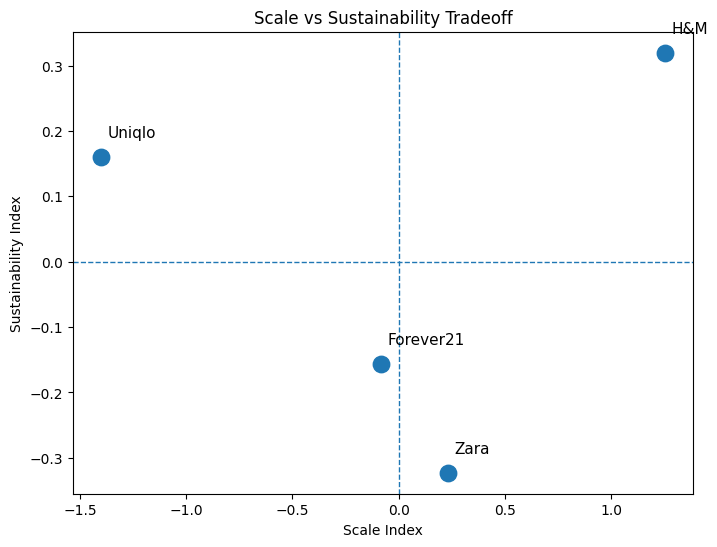

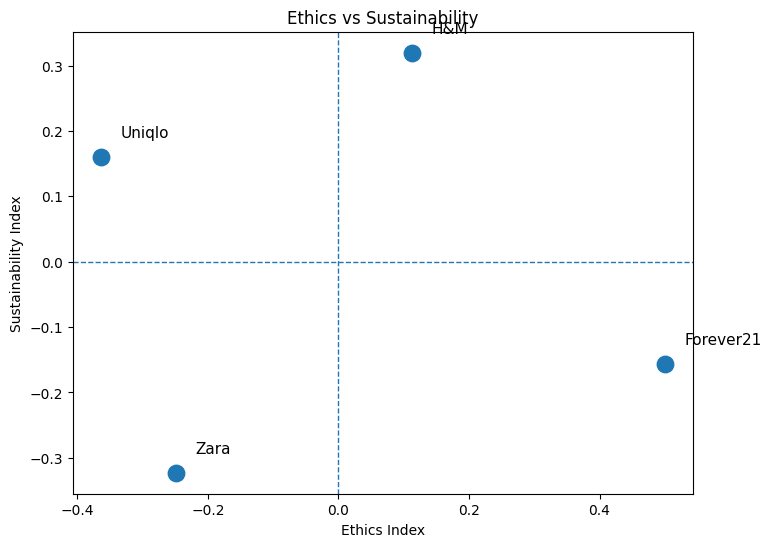

,Scale_Index,Ethics_Index,Sustainability_Index
Scale_Index,1.000000,0.430729,0.120034
Ethics_Index,0.430729,1.000000,-0.057335
Sustainability_Index,0.120034,-0.057335,1.000000


,brand,Scale_Label,Ethics_Label,Sustainability_Label
0,Forever21,Low,High,Low
1,H&M,High,High,High
2,Uniqlo,Low,Low,High
3,Zara,High,Low,Low


,brand,Scale_Index,Ethics_Index,Sustainability_Index,Scale_Label,Ethics_Label,Sustainability_Label
1,H&M,1.252750,0.113040,0.319723,High,High,High
3,Zara,0.231708,-0.249132,-0.322870,High,Low,Low
0,Forever21,-0.083256,0.499879,-0.156380,Low,High,Low
2,Uniqlo,-1.401203,-0.363787,0.159528,Low,Low,High


In [19]:
# -------------------------------
# TRADEOFF TABLE
# -------------------------------

tradeoff_table = df_brand[[
    "brand",
    "Scale_Index",
    "Ethics_Index",
    "Sustainability_Index"
]].sort_values(by="Scale_Index", ascending=False)

display(tradeoff_table)

# -------------------------------
# SCALE VS ETHICS
# -------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df_brand["Scale_Index"], df_brand["Ethics_Index"], s=140)

for _, row in df_brand.iterrows():
    plt.text(row["Scale_Index"] + 0.03, row["Ethics_Index"] + 0.03, row["brand"], fontsize=11)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Scale Index")
plt.ylabel("Ethics Index")
plt.title("Scale vs Ethics Tradeoff")
plt.show()

# -------------------------------
# SCALE VS SUSTAINABILITY
# -------------------------------

plt.figure(figsize=(8, 6))
plt.scatter(df_brand["Scale_Index"], df_brand["Sustainability_Index"], s=140)

for _, row in df_brand.iterrows():
    plt.text(row["Scale_Index"] + 0.03, row["Sustainability_Index"] + 0.03, row["brand"], fontsize=11)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Scale Index")
plt.ylabel("Sustainability Index")
plt.title("Scale vs Sustainability Tradeoff")
plt.show()

# -------------------------------
# ETHICS VS SUSTAINABILITY
# -------------------------------

plt.figure(figsize=(8, 6))
plt.scatter(df_brand["Ethics_Index"], df_brand["Sustainability_Index"], s=140)

for _, row in df_brand.iterrows():
    plt.text(row["Ethics_Index"] + 0.03, row["Sustainability_Index"] + 0.03, row["brand"], fontsize=11)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Ethics Index")
plt.ylabel("Sustainability Index")
plt.title("Ethics vs Sustainability")
plt.show()

# -------------------------------
# CORRELATIONS BETWEEN DIMENSIONS
# -------------------------------

corr_table = df_brand[[
    "Scale_Index",
    "Ethics_Index",
    "Sustainability_Index"
]].corr()

display(corr_table)

# -------------------------------
# SIMPLE BRAND CLASSIFICATION
# -------------------------------

def label_position(value):
    return "High" if value > 0 else "Low"

df_brand["Scale_Label"] = df_brand["Scale_Index"].apply(label_position)
df_brand["Ethics_Label"] = df_brand["Ethics_Index"].apply(label_position)
df_brand["Sustainability_Label"] = df_brand["Sustainability_Index"].apply(label_position)

display(df_brand[[
    "brand",
    "Scale_Label",
    "Ethics_Label",
    "Sustainability_Label"
]])

# -------------------------------
# SUMMARY TABLE
# -------------------------------

summary_table = df_brand[[
    "brand",
    "Scale_Index",
    "Ethics_Index",
    "Sustainability_Index",
    "Scale_Label",
    "Ethics_Label",
    "Sustainability_Label"
]].sort_values(by="Scale_Index", ascending=False)

display(summary_table)

RANDOM FOREST RESULTS
Target: Sustainability_Index
RMSE: 0.259
R^2: -0.0136

Top Feature Importances:


,feature,importance
4,customer_rating,0.157504
10,log_stock,0.107162
3,stock_quantity,0.101912
1,original_price,0.093573
0,current_price,0.090150
9,log_original_price,0.089312
8,log_price,0.087538
6,price_gap,0.069812
2,markdown_percentage,0.060369
17,season_Summer,0.026599



Top 10 products with highest predicted sustainability:


,product_id,brand,Predicted_Sustainability
918,FB001811,H&M,0.199997
898,FB001772,Uniqlo,0.192781
943,FB001867,H&M,0.165551
24,FB000051,H&M,0.163203
352,FB000702,H&M,0.157711
257,FB000508,H&M,0.152082
800,FB001559,H&M,0.147989
291,FB000577,H&M,0.144610
108,FB000216,H&M,0.138787
628,FB001220,H&M,0.136547



Top 10 products with lowest predicted sustainability:


,product_id,brand,Predicted_Sustainability
1061,FB002082,Zara,-0.191647
884,FB001751,Zara,-0.185900
28,FB000058,Zara,-0.180689
256,FB000506,Zara,-0.173875
50,FB000101,Zara,-0.161732
513,FB001007,Zara,-0.161232
504,FB000985,Zara,-0.161175
796,FB001545,Zara,-0.158816
138,FB000255,Zara,-0.156164
593,FB001162,Zara,-0.155948



Brand-level average predicted sustainability:


,brand,Avg_Predicted_Sustainability,Avg_Actual_Sustainability,Avg_Price,Avg_Rating,Return_Rate
1,H&M,0.042906,0.319723,87.983948,3.036481,0.141631
2,Uniqlo,0.008508,0.159528,89.940507,3.110599,0.110599
0,Forever21,-0.051166,-0.156380,80.213491,2.969811,0.150943
3,Zara,-0.072041,-0.322870,83.200226,2.905639,0.165414


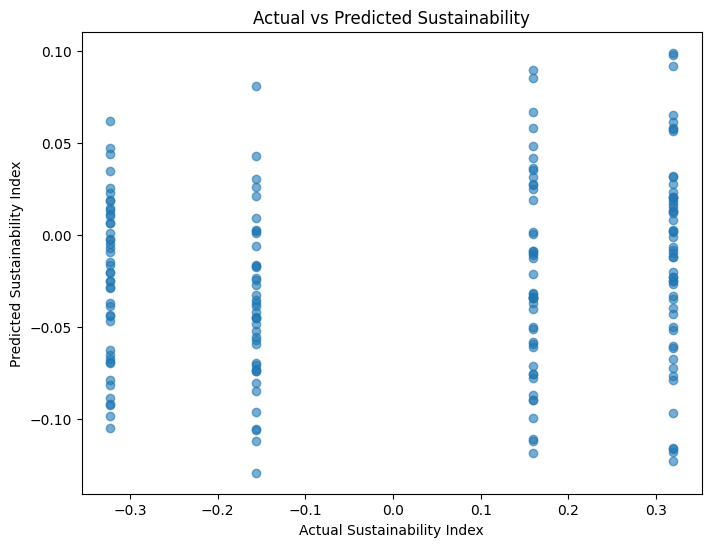

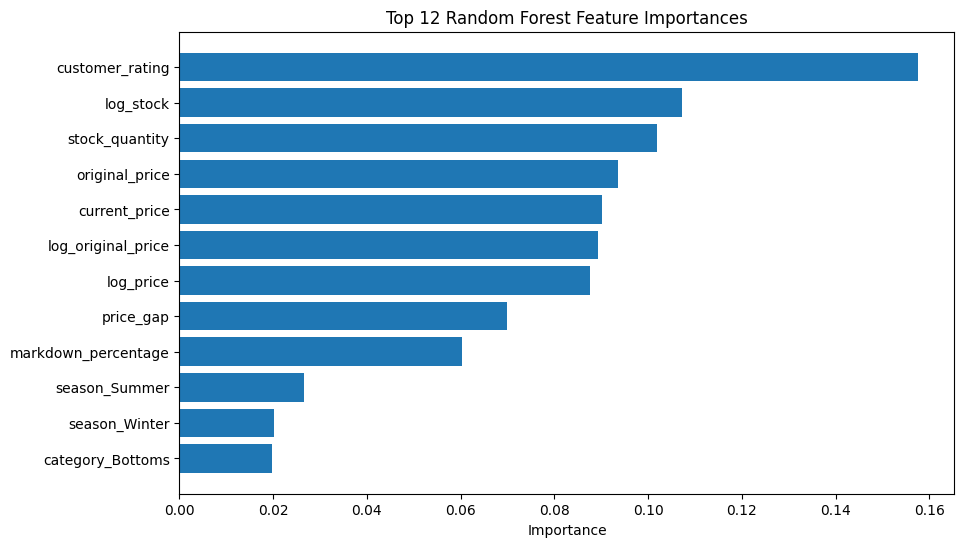


Simulation: effect of +10% current price on predicted sustainability


,brand,baseline_prediction,after_price_increase,change
3,Zara,-0.072041,-0.057529,0.014512
0,Forever21,-0.051166,-0.043617,0.007549
2,Uniqlo,0.008508,0.006384,-0.002124
1,H&M,0.042906,0.035529,-0.007377


In [20]:
# =========================================================
# RANDOM FOREST: PREDICT HIDDEN SUSTAINABILITY FROM PRODUCT SIGNALS
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ---------------------------------------------------------
# 1. MERGE BRAND-LEVEL INDICES BACK INTO PRODUCT-LEVEL DATA
# ---------------------------------------------------------
# This assumes df_brand already has:
# - brand
# - Scale_Index
# - Ethics_Index
# - Sustainability_Index

df_model = df_final.merge(
    df_brand[["brand", "Scale_Index", "Ethics_Index", "Sustainability_Index"]],
    on="brand",
    how="left"
).copy()

# ---------------------------------------------------------
# 2. BASIC CLEANUP + FEATURE ENGINEERING
# ---------------------------------------------------------
df_model = df_model.drop(columns=["brand_cleaned"], errors="ignore")

# Make sure is_returned is numeric
df_model["is_returned"] = df_model["is_returned"].astype(int)

# Feature engineering
df_model["price_gap"] = df_model["original_price"] - df_model["current_price"]
df_model["discount_flag"] = (df_model["markdown_percentage"] > 0).astype(int)
df_model["log_price"] = np.log1p(df_model["current_price"])
df_model["log_original_price"] = np.log1p(df_model["original_price"])
df_model["log_stock"] = np.log1p(df_model["stock_quantity"])

# Optional: one-hot encode category and season
df_model = pd.get_dummies(df_model, columns=["category", "season"], drop_first=True)

# ---------------------------------------------------------
# 3. CHOOSE TARGET
# ---------------------------------------------------------
# You can switch this to "Ethics_Index" if you want
target = "Sustainability_Index"

# ---------------------------------------------------------
# 4. DEFINE FEATURES
# ---------------------------------------------------------
base_features = [
    "current_price",
    "original_price",
    "markdown_percentage",
    "stock_quantity",
    "customer_rating",
    "is_returned",
    "price_gap",
    "discount_flag",
    "log_price",
    "log_original_price",
    "log_stock"
]

category_features = [col for col in df_model.columns if col.startswith("category_")]
season_features = [col for col in df_model.columns if col.startswith("season_")]

features = base_features + category_features + season_features

# Keep only rows with complete data
df_model = df_model[features + [target, "brand", "product_id"]].dropna().copy()

# ---------------------------------------------------------
# 5. TRAIN / TEST SPLIT
# ---------------------------------------------------------
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# 6. TRAIN RANDOM FOREST
# ---------------------------------------------------------
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

# ---------------------------------------------------------
# 7. EVALUATE MODEL
# ---------------------------------------------------------
y_pred = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("===================================")
print("RANDOM FOREST RESULTS")
print("Target:", target)
print("RMSE:", round(rmse, 4))
print("R^2:", round(r2, 4))
print("===================================")

# ---------------------------------------------------------
# 8. FEATURE IMPORTANCE
# ---------------------------------------------------------
importance_df = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop Feature Importances:")
display(importance_df.head(15))

# ---------------------------------------------------------
# 9. ADD PREDICTIONS BACK TO DATA
# ---------------------------------------------------------
df_model["Predicted_Sustainability"] = rf_model.predict(X)

# ---------------------------------------------------------
# 10. PRODUCT-LEVEL RANKINGS
# ---------------------------------------------------------
print("\nTop 10 products with highest predicted sustainability:")
display(
    df_model[["product_id", "brand", "Predicted_Sustainability"]]
    .sort_values(by="Predicted_Sustainability", ascending=False)
    .head(10)
)

print("\nTop 10 products with lowest predicted sustainability:")
display(
    df_model[["product_id", "brand", "Predicted_Sustainability"]]
    .sort_values(by="Predicted_Sustainability", ascending=True)
    .head(10)
)

# ---------------------------------------------------------
# 11. BRAND-LEVEL AVERAGE PREDICTIONS
# ---------------------------------------------------------
brand_pred = (
    df_model.groupby("brand")
    .agg(
        Avg_Predicted_Sustainability=("Predicted_Sustainability", "mean"),
        Avg_Actual_Sustainability=(target, "mean"),
        Avg_Price=("current_price", "mean"),
        Avg_Rating=("customer_rating", "mean"),
        Return_Rate=("is_returned", "mean")
    )
    .reset_index()
    .sort_values(by="Avg_Predicted_Sustainability", ascending=False)
)

print("\nBrand-level average predicted sustainability:")
display(brand_pred)

# ---------------------------------------------------------
# 12. ACTUAL VS PREDICTED SCATTER
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Sustainability Index")
plt.ylabel("Predicted Sustainability Index")
plt.title("Actual vs Predicted Sustainability")
plt.show()

# ---------------------------------------------------------
# 13. FEATURE IMPORTANCE BAR CHART
# ---------------------------------------------------------
top_n = 12
top_importance = importance_df.head(top_n).sort_values(by="importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.xlabel("Importance")
plt.title(f"Top {top_n} Random Forest Feature Importances")
plt.show()

# ---------------------------------------------------------
# 14. SIMPLE SIMULATION: WHAT IF PRICE INCREASES BY 10%?
# ---------------------------------------------------------
df_sim = df_model.copy()

df_sim["current_price"] = df_sim["current_price"] * 1.10
df_sim["price_gap"] = df_sim["original_price"] - df_sim["current_price"]
df_sim["discount_flag"] = (df_sim["markdown_percentage"] > 0).astype(int)
df_sim["log_price"] = np.log1p(df_sim["current_price"])
df_sim["log_original_price"] = np.log1p(df_sim["original_price"])
df_sim["log_stock"] = np.log1p(df_sim["stock_quantity"])

X_sim = df_sim[features]
df_sim["Predicted_Sustainability_After_10pct_Price_Increase"] = rf_model.predict(X_sim)

simulation_summary = pd.DataFrame({
    "brand": df_model["brand"],
    "baseline_prediction": df_model["Predicted_Sustainability"],
    "after_price_increase": df_sim["Predicted_Sustainability_After_10pct_Price_Increase"]
})

simulation_summary = (
    simulation_summary.groupby("brand")
    .mean()
    .reset_index()
)

simulation_summary["change"] = (
    simulation_summary["after_price_increase"] - simulation_summary["baseline_prediction"]
)

print("\nSimulation: effect of +10% current price on predicted sustainability")
display(simulation_summary.sort_values(by="change", ascending=False))

In [21]:
# ============================================
# STEP 1: BUILD FINAL BRAND-LEVEL SIMULATOR TABLE
# ============================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# --------------------------------------------
# 1. Aggregate raw cost/sustainability data to brand level
# --------------------------------------------
df_brand = df_costs_filtered.groupby("brand_cleaned").agg({
    "Monthly_Production_Tonnes": "mean",
    "Release_Cycles_Per_Year": "mean",
    "GDP_Contribution_Million_USD": "mean",
    "Avg_Worker_Wage_USD": "mean",
    "Transparency_Index": "mean",
    "Compliance_Score": "mean",
    "Ethical_Rating": "mean",
    "Carbon_Emissions_tCO2e": "mean",
    "Water_Usage_Million_Litres": "mean",
    "Landfill_Waste_Tonnes": "mean",
    "Env_Cost_Index": "mean",
    "Sustainability_Score": "mean"
}).reset_index()

df_brand = df_brand.rename(columns={"brand_cleaned": "brand"})

# --------------------------------------------
# 2. Define interpretable groups
# --------------------------------------------
scale_features = [
    "Monthly_Production_Tonnes",
    "Release_Cycles_Per_Year",
    "GDP_Contribution_Million_USD"
]

ethics_features = [
    "Avg_Worker_Wage_USD",
    "Transparency_Index",
    "Compliance_Score",
    "Ethical_Rating"
]

sustainability_features = [
    "Carbon_Emissions_tCO2e",
    "Water_Usage_Million_Litres",
    "Landfill_Waste_Tonnes",
    "Env_Cost_Index",
    "Sustainability_Score"
]

# --------------------------------------------
# 3. Create a standardized copy for index construction
#    Flip "bad" sustainability variables so higher = better
# --------------------------------------------
df_index = df_brand.copy()

df_index["Carbon_Emissions_tCO2e"] = -df_index["Carbon_Emissions_tCO2e"]
df_index["Water_Usage_Million_Litres"] = -df_index["Water_Usage_Million_Litres"]
df_index["Landfill_Waste_Tonnes"] = -df_index["Landfill_Waste_Tonnes"]
df_index["Env_Cost_Index"] = -df_index["Env_Cost_Index"]

all_index_features = scale_features + ethics_features + sustainability_features

scaler = StandardScaler()
df_index[all_index_features] = scaler.fit_transform(df_index[all_index_features])

# --------------------------------------------
# 4. Build the 3 indices
# --------------------------------------------
df_brand["Scale_Index"] = df_index[scale_features].mean(axis=1)
df_brand["Ethics_Index"] = df_index[ethics_features].mean(axis=1)
df_brand["Sustainability_Index"] = df_index[sustainability_features].mean(axis=1)

# --------------------------------------------
# 5. Add simple labels for easier interpretation
# --------------------------------------------
def high_low_label(x):
    return "High" if x > 0 else "Low"

df_brand["Scale_Label"] = df_brand["Scale_Index"].apply(high_low_label)
df_brand["Ethics_Label"] = df_brand["Ethics_Index"].apply(high_low_label)
df_brand["Sustainability_Label"] = df_brand["Sustainability_Index"].apply(high_low_label)

# --------------------------------------------
# 6. Final simulator table
# --------------------------------------------
simulator_cols = [
    "brand",
    "Monthly_Production_Tonnes",
    "Release_Cycles_Per_Year",
    "GDP_Contribution_Million_USD",
    "Avg_Worker_Wage_USD",
    "Transparency_Index",
    "Compliance_Score",
    "Ethical_Rating",
    "Carbon_Emissions_tCO2e",
    "Water_Usage_Million_Litres",
    "Landfill_Waste_Tonnes",
    "Env_Cost_Index",
    "Sustainability_Score",
    "Scale_Index",
    "Ethics_Index",
    "Sustainability_Index",
    "Scale_Label",
    "Ethics_Label",
    "Sustainability_Label"
]

df_simulator = df_brand[simulator_cols].copy()

# --------------------------------------------
# 7. Check output
# --------------------------------------------
print(df_simulator.shape)
display(df_simulator)

# Make a cleaner display table for the simulator
df_display = df_simulator.copy()

# Convert indices to 0-100 style scores
for col in ["Scale_Index", "Ethics_Index", "Sustainability_Index"]:
    min_val = df_display[col].min()
    max_val = df_display[col].max()
    df_display[col.replace("_Index", "_Score")] = (
        (df_display[col] - min_val) / (max_val - min_val) * 100
    )

# Round for readability
score_cols = ["Scale_Score", "Ethics_Score", "Sustainability_Score"]
df_display[score_cols] = df_display[score_cols].round(1)

# Keep only the most useful columns
df_display = df_display[[
    "brand",
    "Scale_Score",
    "Ethics_Score",
    "Sustainability_Score",
    "Scale_Label",
    "Ethics_Label",
    "Sustainability_Label"
]]

display(df_display.sort_values(by="Sustainability_Score", ascending=False))

(4, 19)


,brand,Monthly_Production_Tonnes,Release_Cycles_Per_Year,GDP_Contribution_Million_USD,Avg_Worker_Wage_USD,Transparency_Index,Compliance_Score,Ethical_Rating,Carbon_Emissions_tCO2e,Water_Usage_Million_Litres,Landfill_Waste_Tonnes,Env_Cost_Index,Sustainability_Score,Scale_Index,Ethics_Index,Sustainability_Index,Scale_Label,Ethics_Label,Sustainability_Label
0,Forever21,497.603517,17.703404,497.179611,148.124360,50.977796,50.662139,2.542771,9933.496596,204.151524,806.964133,0.552058,49.599028,-0.083256,0.499879,-0.156380,Low,High,Low
1,H&M,500.261292,17.749231,508.633200,150.729800,49.369415,49.923015,2.503569,10084.840031,197.993338,791.433800,0.561277,50.326646,1.252750,0.113040,0.319723,High,High,High
2,Uniqlo,489.621188,17.621343,496.346472,148.684940,47.848313,49.294492,2.552685,10097.616420,204.579880,789.363201,0.541549,49.732840,-1.401203,-0.363787,0.159528,Low,Low,High
3,Zara,497.465264,17.704620,501.830363,149.846832,50.613696,48.735314,2.504950,9945.682261,202.061403,794.568927,0.564356,47.796551,0.231708,-0.249132,-0.322870,High,Low,Low


,brand,Scale_Score,Ethics_Score,Sustainability_Score,Scale_Label,Ethics_Label,Sustainability_Label
1,H&M,100.0,55.2,100.0,High,High,High
2,Uniqlo,0.0,0.0,75.1,Low,Low,High
0,Forever21,49.7,100.0,25.9,Low,High,Low
3,Zara,61.5,13.3,0.0,High,Low,Low
